# Quantitative Framework: WES vs in situ CNV for One Denoising Run

This notebook uses the shared quantitative CNV validation framework to score one denoising result against WES.


## Inputs


In [38]:
from pathlib import Path

wes_file = Path('/home/augusta/storage3/augusta/insituCNV/data_from_Kang/sample_selection/WES_PureCN/WES_PureCN_output.csv')

#insitu_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_log_norm.csv')
#insitu_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_smooth.csv')
insitu_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_magic.csv')

sample_name = '1105_BL'
bin_size_bp = 20_000_000
min_genes_per_bin = 5


#output_subdir = 'results_log_norm'
#output_subdir = 'results_smooth'
output_subdir = 'results_magic'

In [39]:
import sys
import pandas as pd

repo_root = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from insitucnv.tl.quantitative_validation import (
    build_output_path,
    build_wes_insitu_comparison_table,
    compute_validation_metrics,
    load_gene_cnv_values,
    load_wes_segments,
    plot_confusion_matrix,
    plot_profile_comparison,
    plot_profile_comparison_lines,
    plot_threshold_scatter,
    plot_truth_overlay,
    rename_threshold_columns,
    resolve_wes_sample_id,
    save_dataframe,
    select_validation_thresholds,
)

NOTEBOOK_DIR = repo_root / 'Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings'
output_dir = NOTEBOOK_DIR / output_subdir
output_dir.mkdir(parents=True, exist_ok=True)


## Load Data And Build Comparison Table


In [40]:
wes_sample_id = resolve_wes_sample_id(sample_name, wes_file)
wes = load_wes_segments(wes_file, wes_sample_id)
insitu = load_gene_cnv_values(insitu_file, value_col='CNV_value')

if not wes:
    raise ValueError(f'No WES rows found for {wes_sample_id}')
if not insitu:
    raise ValueError(f'No in situ rows found in {insitu_file}')

metric_df, axis = build_wes_insitu_comparison_table(
    wes=wes,
    insitu=insitu,
    bin_size_bp=bin_size_bp,
    min_genes_per_bin=min_genes_per_bin,
)

if metric_df.empty:
    raise ValueError('No comparison rows were created. Try a smaller bin size or fewer min_genes_per_bin.')

comparison_title = (
    'Raw WES vs in situ comparison'
    if bin_size_bp is None
    else f'Binned WES vs in situ comparison (bin_size={bin_size_bp:,}, min_genes={min_genes_per_bin})'
)

print('Resolved sample mapping')
print('  WES sampleID   :', wes_sample_id)
print('  in situ file   :', insitu_file)
print('  comparison rows:', len(metric_df))
print('  output_dir     :', output_dir)

display(metric_df.head())


Resolved sample mapping
  WES sampleID   : UE-2971-1105-0
  in situ file   : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_magic.csv
  comparison rows: 146
  output_dir     : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic


,mode,chr_num,start,end,x,wes_segmean,insitu_value,n_genes
0,binned,1,1,20000000,10000000.5,0.036722,0.000812,63
1,binned,1,20000001,40000000,30000000.5,0.019465,0.009447,82
2,binned,1,40000001,60000000,50000000.5,0.019465,0.024629,45
3,binned,1,60000001,80000000,70000000.5,0.019465,0.000587,21
4,binned,1,80000001,100000000,90000000.5,0.019465,0.000014,21


## Comparison Plots


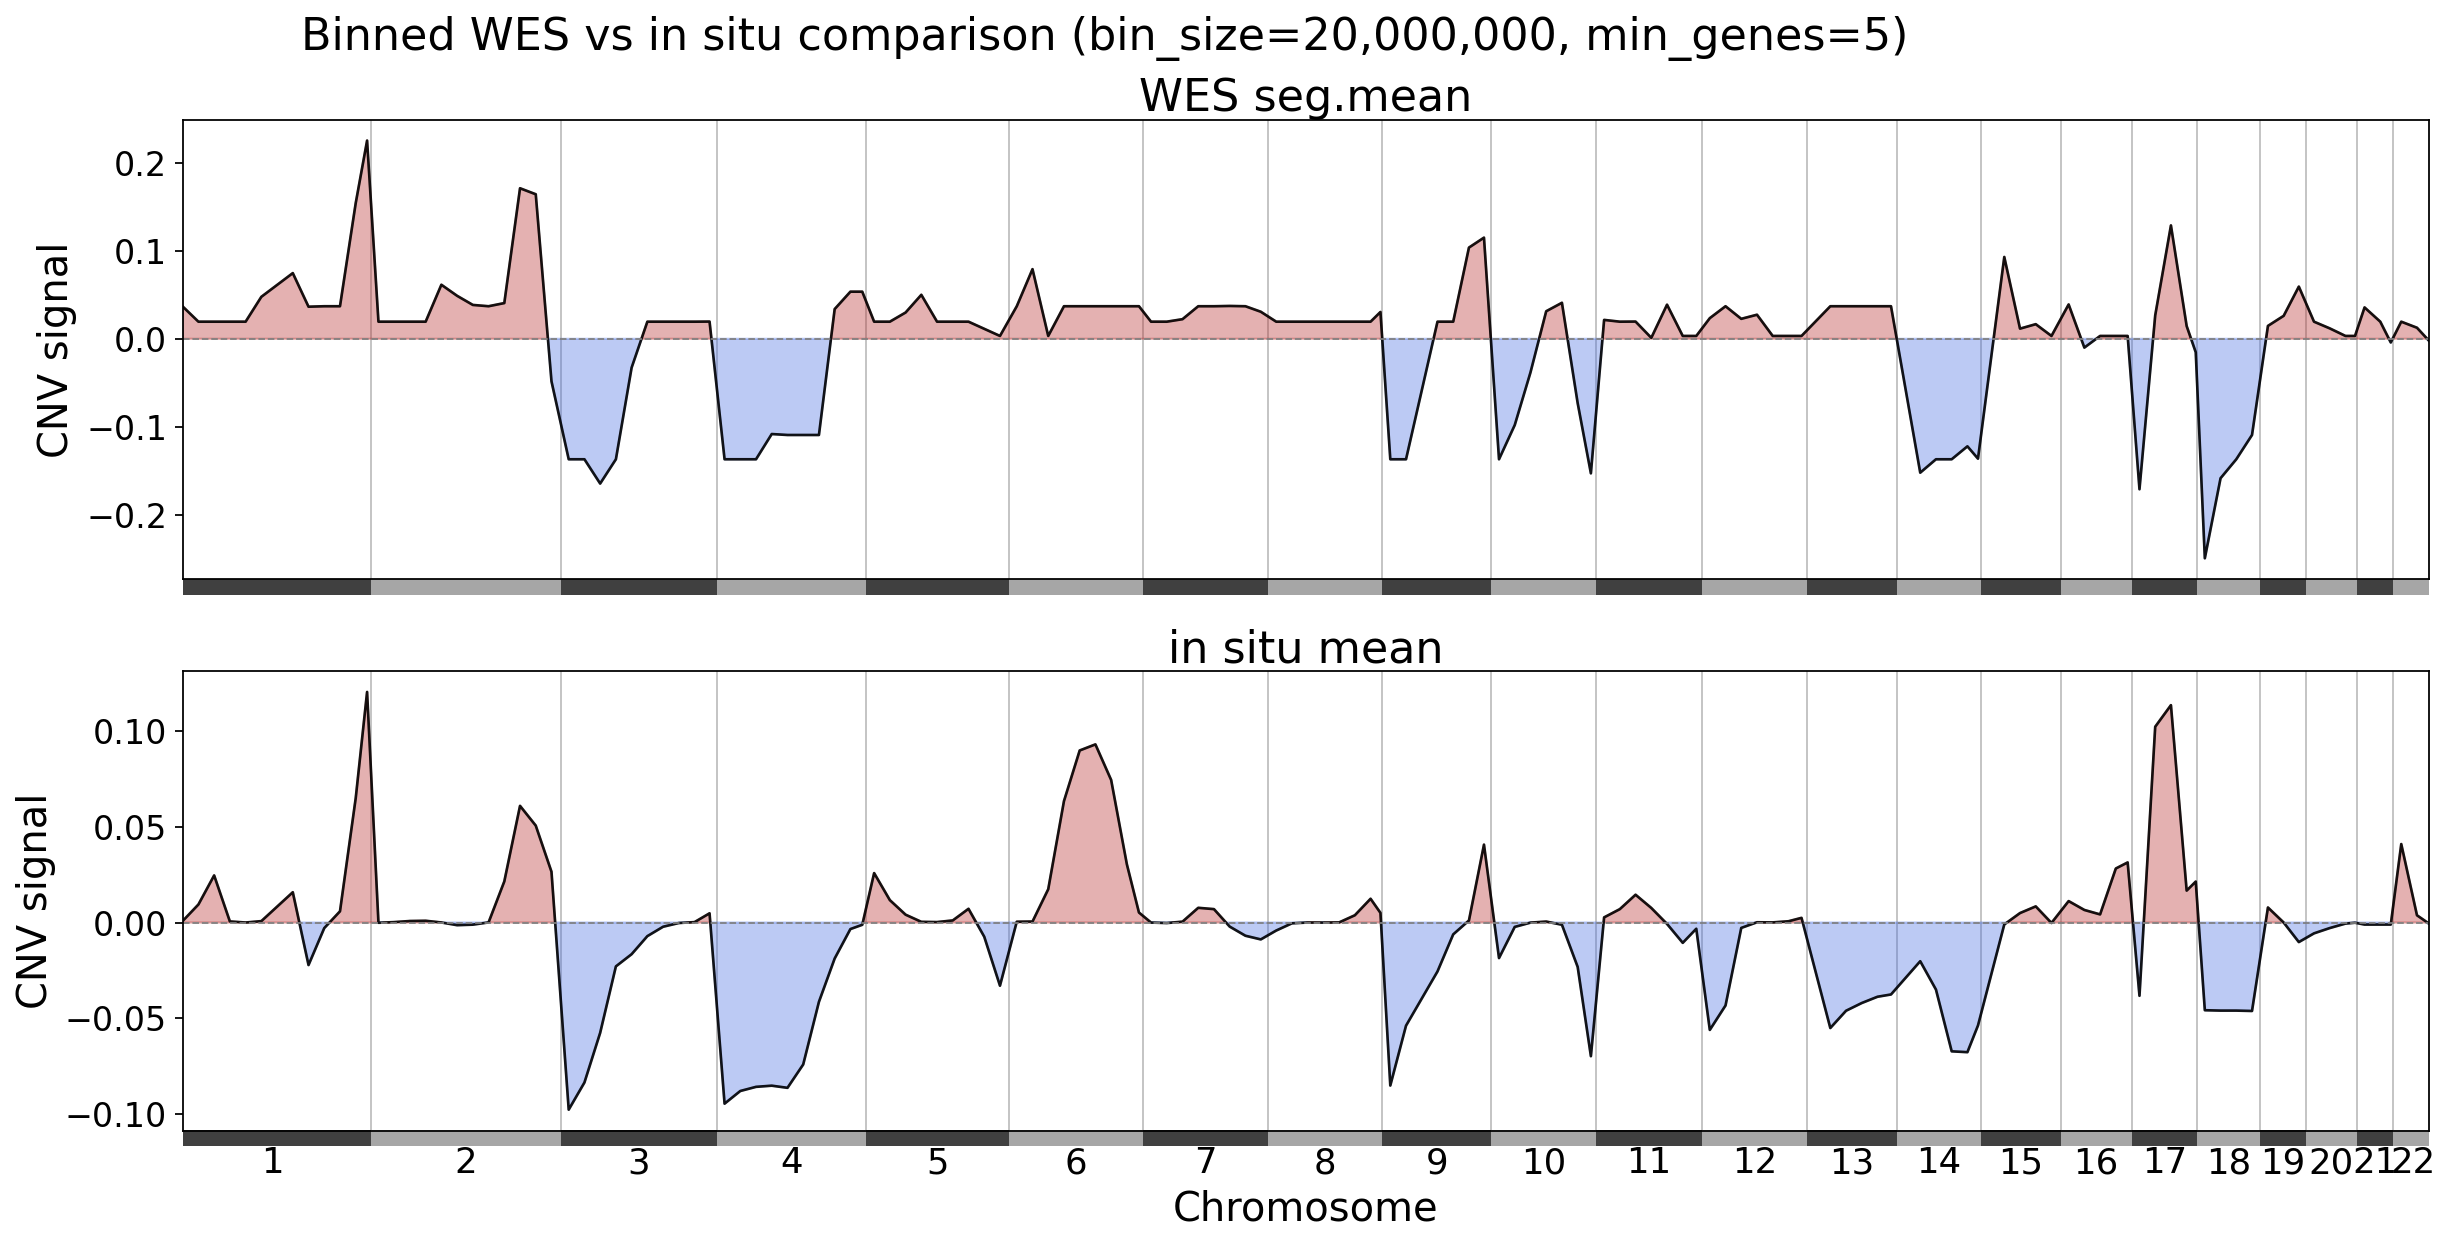

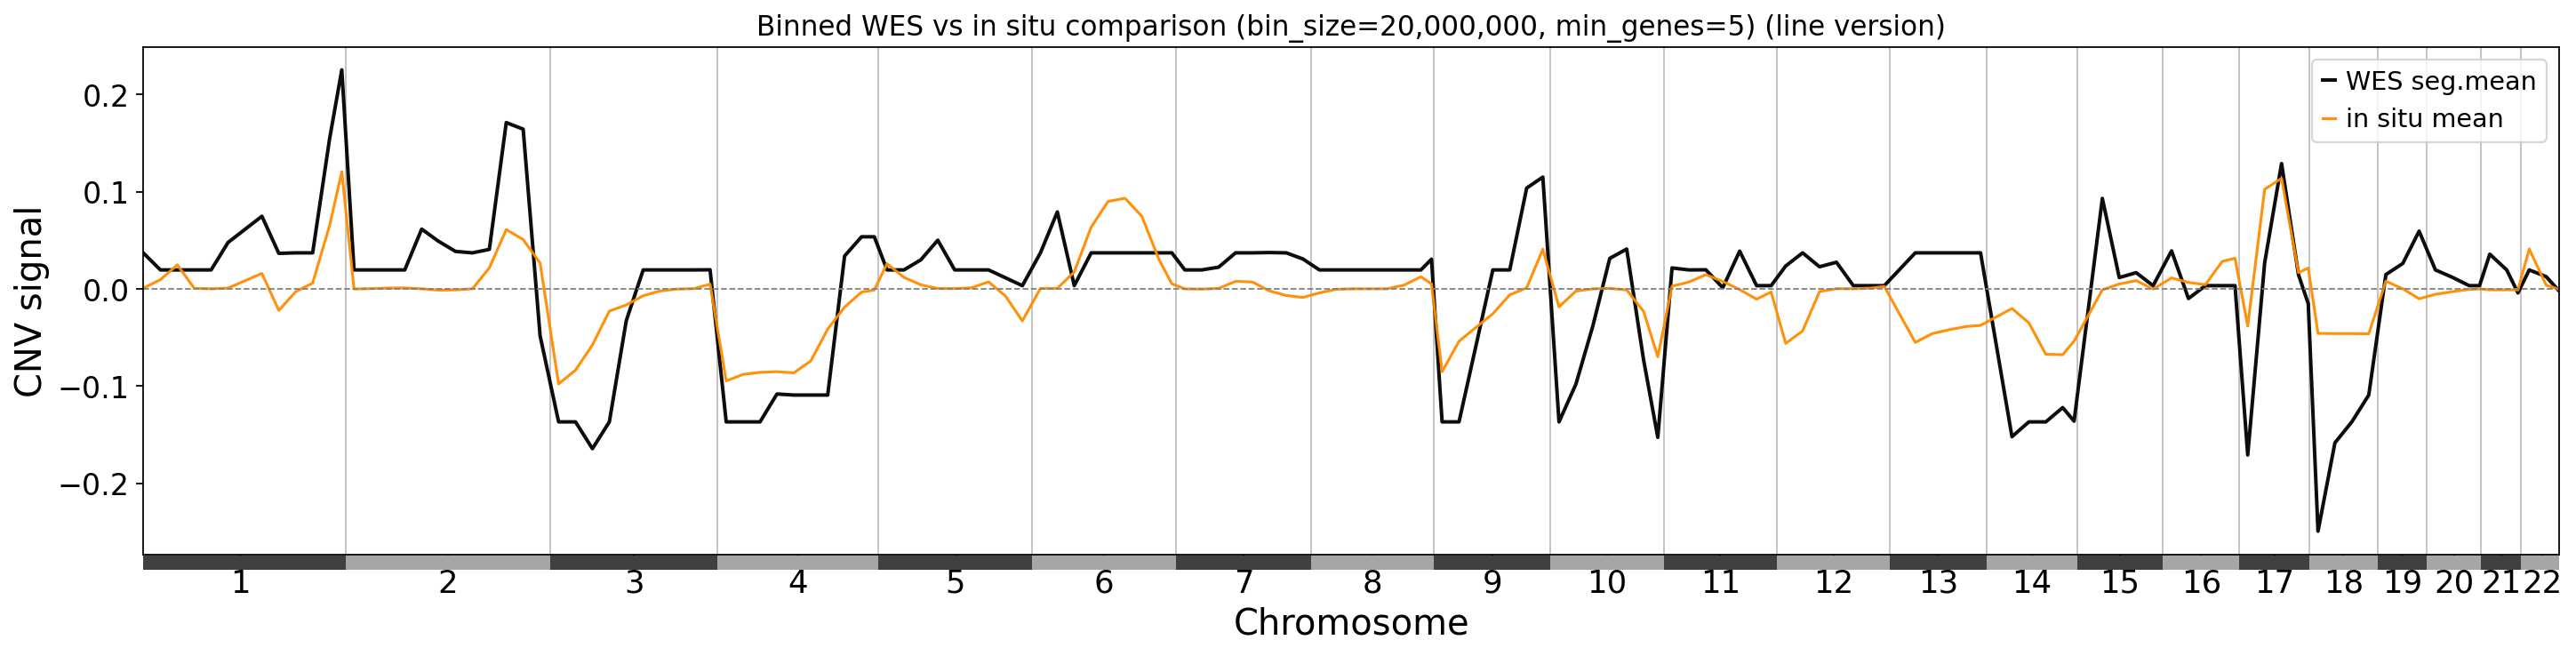

PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__comparison_plot_line.pdf')

In [41]:
plot_profile_comparison(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES seg.mean',
    pred_label='in situ mean' if bin_size_bp is not None else 'in situ value',
    title=comparison_title,
    ylabel='CNV signal',
    output_dir=output_dir,
    sample_name=sample_name,
)

plot_profile_comparison_lines(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES seg.mean',
    pred_label='in situ mean' if bin_size_bp is not None else 'in situ value',
    title=comparison_title + ' (line version)',
    ylabel='CNV signal',
    output_dir=output_dir,
    sample_name=sample_name,
)


## Threshold Selection


In [42]:
wes_thr, insitu_thr, wes_threshold_grid_df, insitu_threshold_grid_df = select_validation_thresholds(
    metric_df=metric_df,
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_threshold_name='wes_threshold',
    pred_threshold_name='insitu_threshold',
)

display(wes_threshold_grid_df.head(10))
display(insitu_threshold_grid_df.head(10))

save_dataframe(wes_threshold_grid_df, output_dir, sample_name, 'wes_threshold_auc_grid', index=False)
save_dataframe(insitu_threshold_grid_df, output_dir, sample_name, 'insitu_threshold_f1_grid', index=False)


,wes_threshold,auc_gain,auc_loss,auc_mean,n_truth_gain,n_truth_loss
0,0.103615,0.976190,0.978182,0.977186,6,25
1,0.108128,0.976190,0.978182,0.977186,6,25
2,0.109209,0.976190,0.970970,0.973580,6,24
3,0.122095,0.980142,0.952778,0.966460,5,20
4,0.114909,0.976190,0.952778,0.964484,6,20
5,0.097953,0.936280,0.970192,0.953236,7,26
6,0.092958,0.875000,0.970192,0.922596,8,26
7,0.061415,0.854412,0.969499,0.911955,10,27
8,0.073007,0.854412,0.969499,0.911955,10,27
9,0.074635,0.849959,0.970192,0.910076,9,26


,insitu_threshold,f1_gain,f1_loss,f1_mean,accuracy_3class
0,0.033000,0.666667,0.814815,0.740741,0.890411
1,0.037583,0.666667,0.807692,0.737179,0.890411
2,0.035033,0.666667,0.792453,0.729560,0.883562
3,0.038270,0.666667,0.784314,0.725490,0.883562
4,0.038774,0.666667,0.784314,0.725490,0.883562
5,0.043338,0.625000,0.808511,0.716755,0.897260
6,0.045812,0.625000,0.808511,0.716755,0.897260
7,0.031421,0.631579,0.800000,0.715789,0.876712
8,0.041021,0.625000,0.800000,0.712500,0.890411
9,0.041420,0.625000,0.800000,0.712500,0.890411


PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__insitu_threshold_f1_grid.csv')

## Metrics And Diagnostics


,sample_name,wes_sample_id,mode,bin_size_bp,min_genes_per_bin,insitu_file,n_rows,wes_threshold,insitu_threshold,auc_gain,...,auc_mean,precision_gain,precision_loss,precision_mean,recall_gain,recall_loss,recall_mean,f1_gain,f1_loss,f1_mean
0,1105_BL,UE-2971-1105-0,binned,20000000,5,1105_BL_tumor_mean_magic.csv,146,0.103615,0.033,0.97619,...,0.977186,0.5,0.758621,0.62931,1.0,0.88,0.94,0.666667,0.814815,0.740741


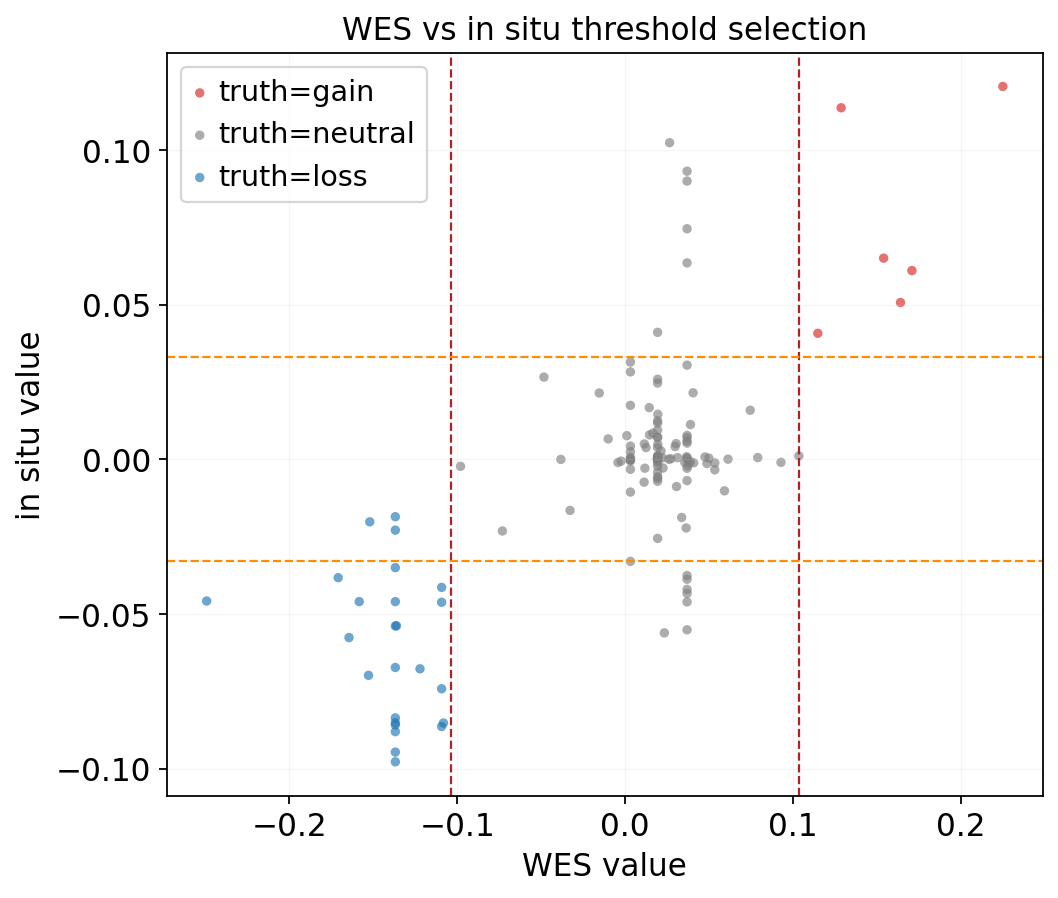

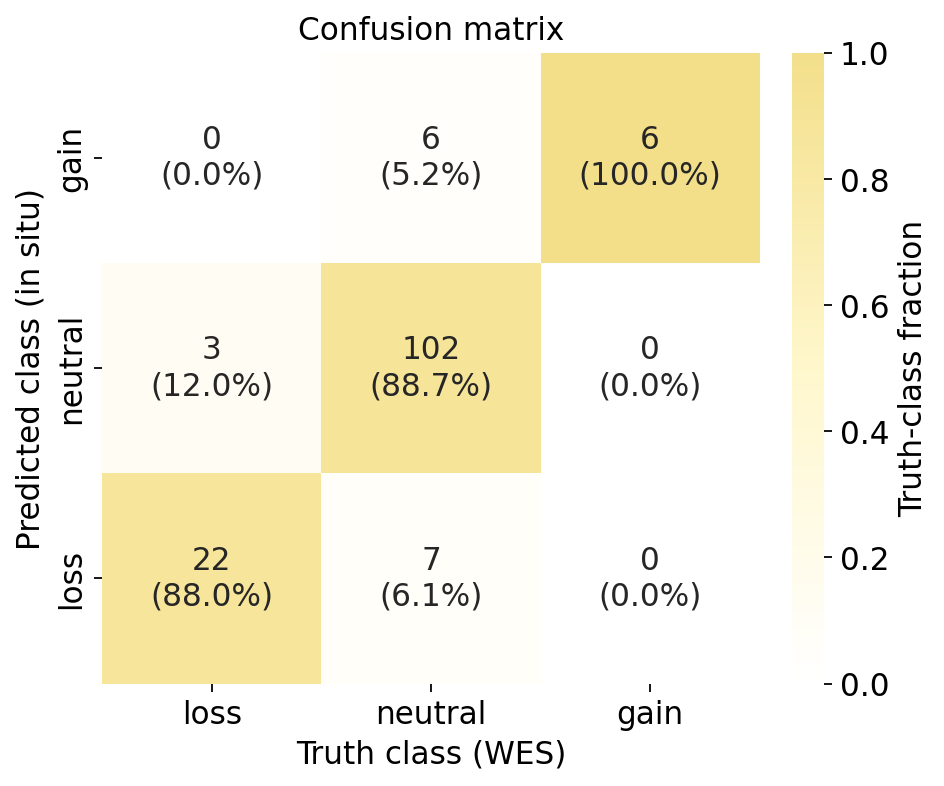

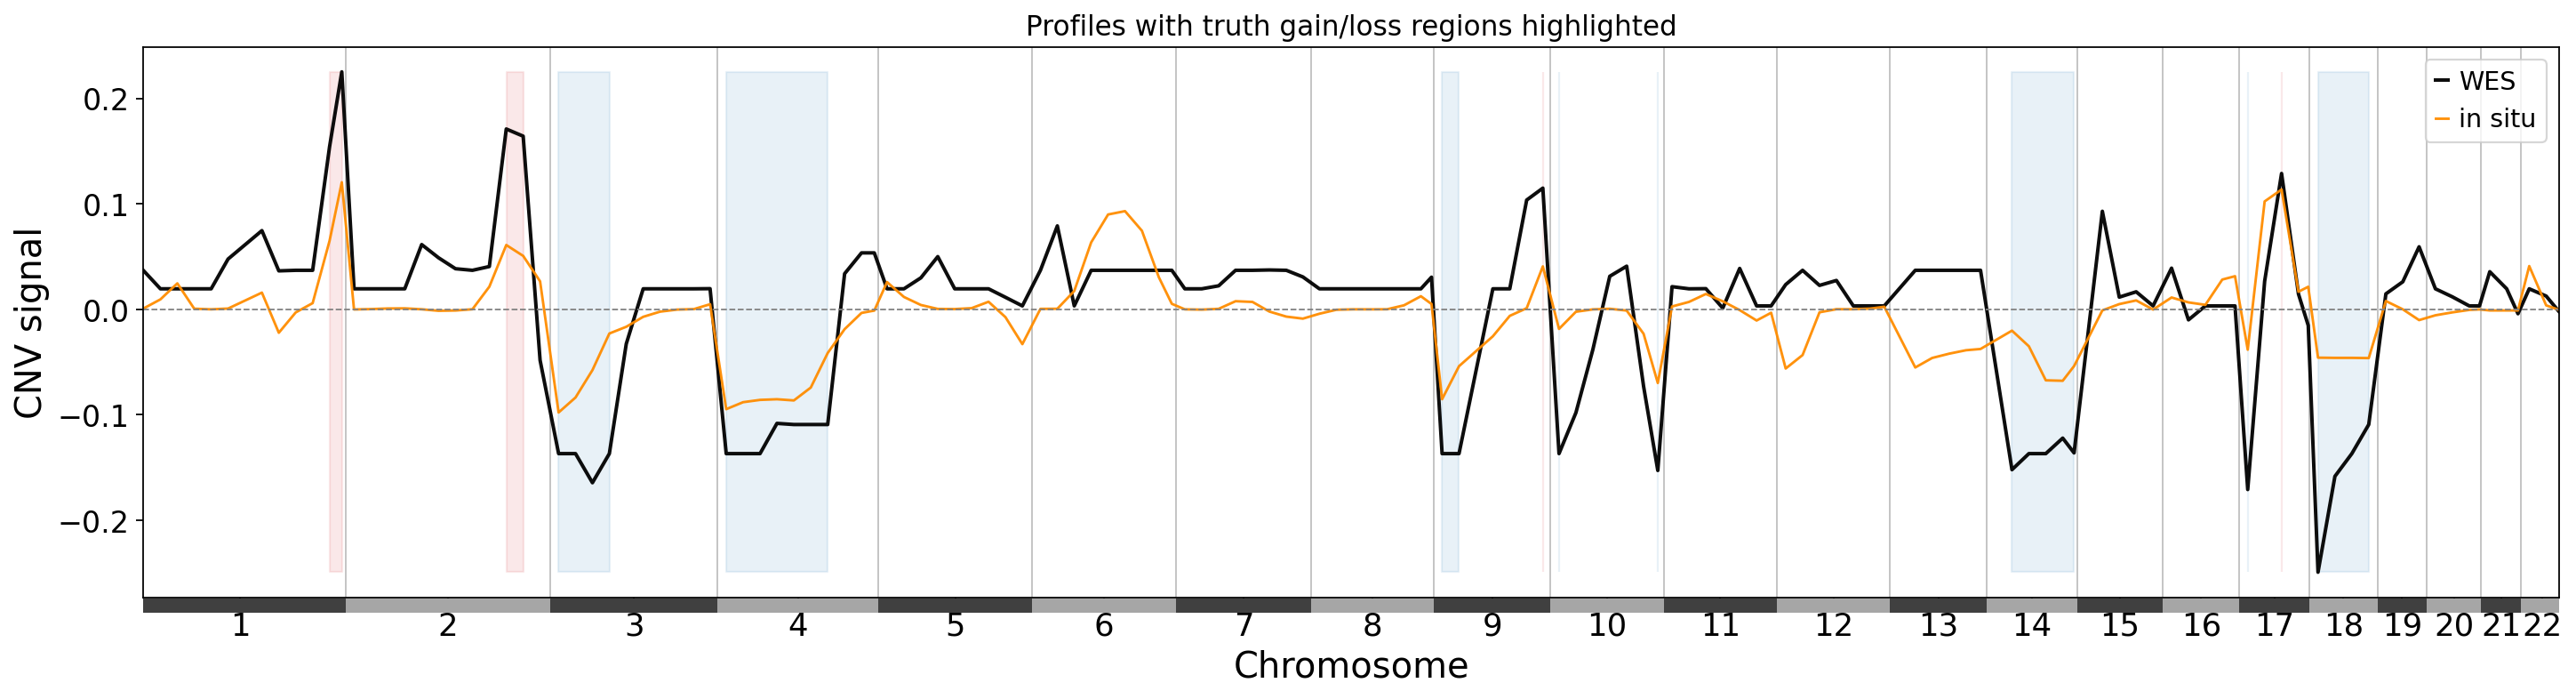

Saved:
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__comparison_plot.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__comparison_plot_line.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__threshold_scatter.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__confusion_matrix.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__truth_overlay.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results_magic/1105BL__metrics_summary.csv
  /home/augusta/storage3/au

In [43]:
metrics_df, truth_labels, pred_labels = compute_validation_metrics(
    metric_df=metric_df,
    truth_thr=wes_thr,
    pred_thr=insitu_thr,
    truth_col='wes_segmean',
    pred_col='insitu_value',
    metadata={
        'sample_name': sample_name,
        'wes_sample_id': wes_sample_id,
        'mode': 'raw' if bin_size_bp is None else 'binned',
        'bin_size_bp': bin_size_bp,
        'min_genes_per_bin': min_genes_per_bin,
        'insitu_file': insitu_file.name,
    },
)
metrics_df = rename_threshold_columns(metrics_df, 'wes_threshold', 'insitu_threshold')
metric_df = metric_df.copy()
metric_df['truth'] = truth_labels
metric_df['pred'] = pred_labels

display(metrics_df)
save_dataframe(metrics_df, output_dir, sample_name, 'metrics_summary', index=False)
save_dataframe(metric_df, output_dir, sample_name, 'comparison_rows', index=False)

plot_threshold_scatter(
    metric_df=metric_df,
    truth_labels=truth_labels,
    truth_thr=wes_thr,
    pred_thr=insitu_thr,
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES',
    pred_label='in situ',
    output_dir=output_dir,
    sample_name=sample_name,
)

cm_counts_df, cm_pct_df = plot_confusion_matrix(
    truth_labels=truth_labels,
    pred_labels=pred_labels,
    truth_label='WES',
    pred_label='in situ',
    output_dir=output_dir,
    sample_name=sample_name,
)

plot_truth_overlay(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES',
    pred_label='in situ',
    output_dir=output_dir,
    sample_name=sample_name,
)

save_dataframe(cm_counts_df.reset_index().rename(columns={'index': 'truth'}), output_dir, sample_name, 'confusion_matrix_counts', index=False)
save_dataframe(cm_pct_df.reset_index().rename(columns={'index': 'truth'}), output_dir, sample_name, 'confusion_matrix_row_pct', index=False)

print('Saved:')
for stem, suffix in [
    ('comparison_plot', '.pdf'),
    ('comparison_plot_line', '.pdf'),
    ('threshold_scatter', '.pdf'),
    ('confusion_matrix', '.pdf'),
    ('truth_overlay', '.pdf'),
    ('metrics_summary', '.csv'),
    ('comparison_rows', '.csv'),
]:
    print(' ', build_output_path(output_dir, sample_name, stem, suffix))
